In [1]:
import sys
from pathlib import Path

THERMOIFT_SRC = Path("../thermoift/src").resolve()
if str(THERMOIFT_SRC) not in sys.path:
    sys.path.insert(0, str(THERMOIFT_SRC))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from thermoift import PLOT_SETTINGS as ps
from matplotlib.ticker import FuncFormatter
from scipy.stats import ks_2samp
from thermoift import MLPreprocessing

In [2]:
dfs = []
JOB_ID = "1693211"

for i in range(100):
    path = f"../DATASET_A4/{JOB_ID}/{JOB_ID}_{i}/CSV/InterfacialProperties/feed_1_interfacial_results.csv"
    
    try:
        df = pd.read_csv(path)
        
        # Invalid Data Removal
        df = df[
            (df["vapor_density"] < 400) &
            (df["interfacial_thickness"] > 0)
        ]
        
        df["source_id"] = i
        dfs.append(df)
    except FileNotFoundError:
        print(f"Missing: {path}")

if not dfs:
    raise FileNotFoundError(f"No interfacial result CSV files found for JOB_ID={JOB_ID!r}")

combined_df = pd.concat(dfs, ignore_index=True)
combined_df = combined_df.dropna(subset=["gamma"])
combined_df.to_csv("interfacial_results_dataset_A4.csv", index=False)

print(f"Combined {len(dfs)} datasets. Total rows: {len(combined_df)}")

Combined 100 datasets. Total rows: 19361


/tmp/ipykernel_2726050/2485544114.py:54: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  corr_annot = corr.applymap(lambda v: rf"${v:.2f}$" if not np.isnan(v) else "")


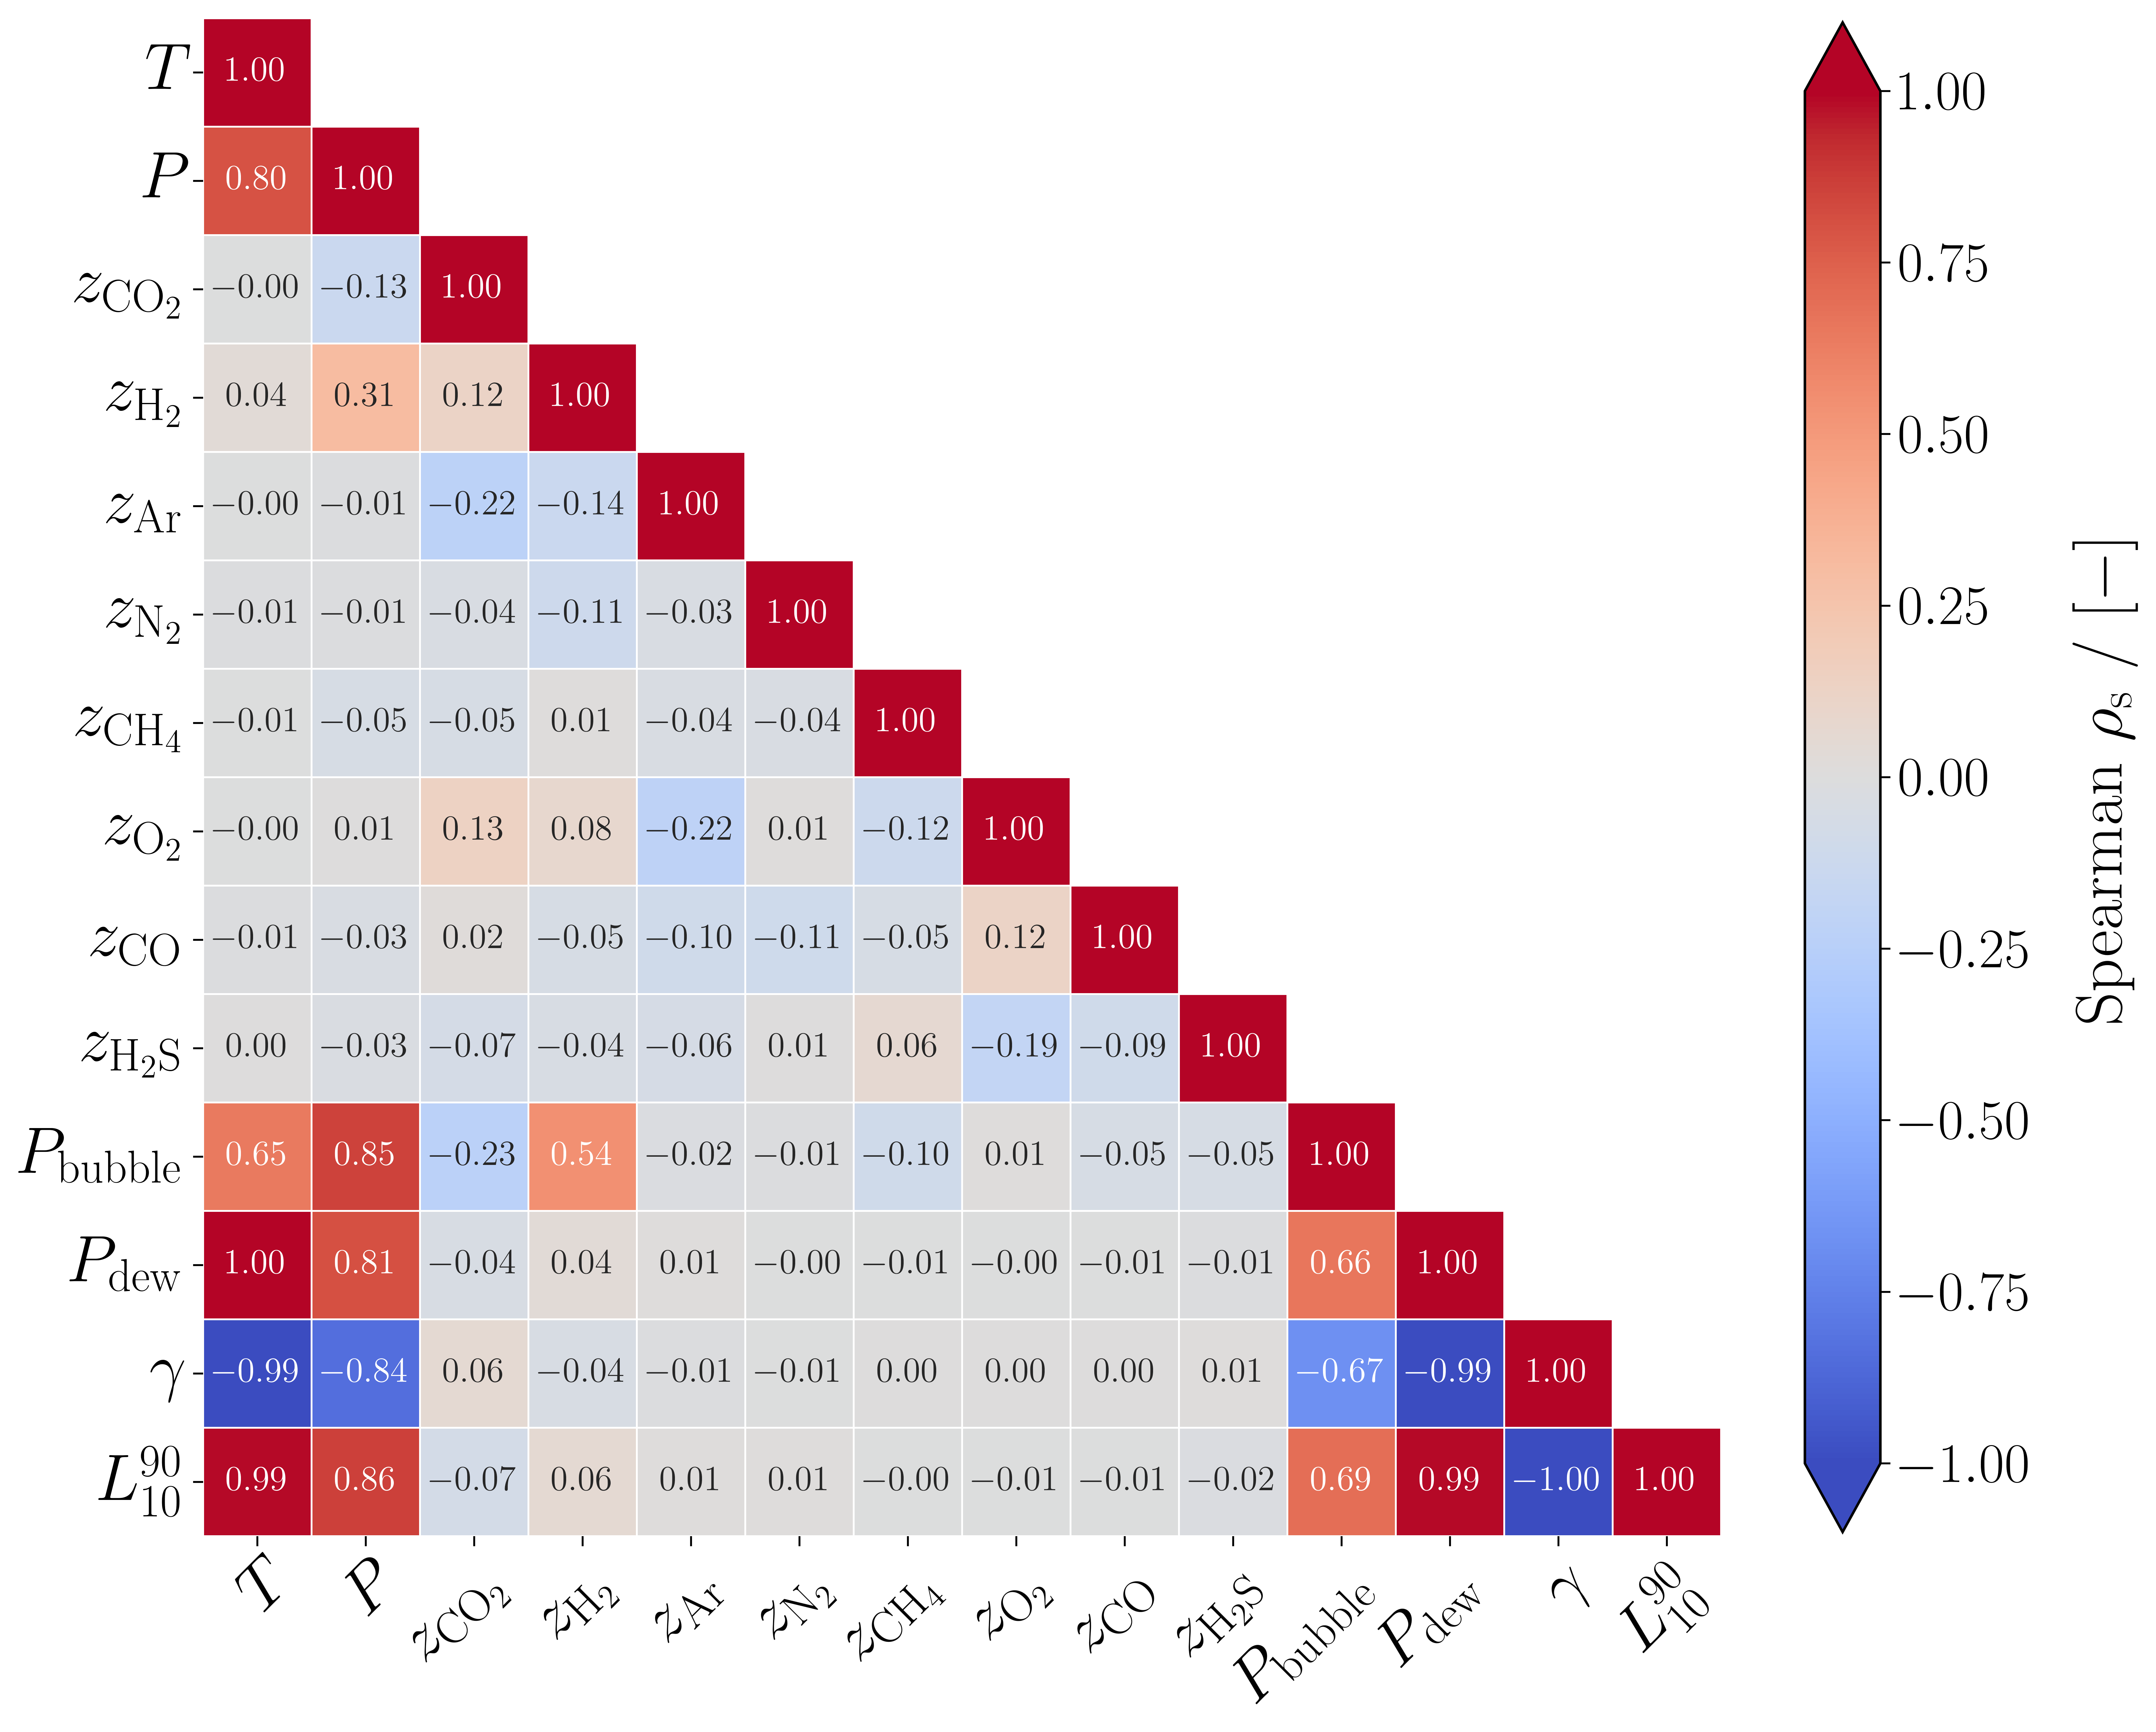

In [3]:

_math_fmt = FuncFormatter(lambda x, _: rf"${x:.2f}$")
# ── columns ──────────────────────────────────────────────────────────────
COMPONENTS = [
    "carbon dioxide", "hydrogen", "argon", "nitrogen",
    "methane", "oxygen", "carbon monoxide", "hydrogen sulfide"
]

z_cols = [f"z_{c}" for c in COMPONENTS if f"z_{c}" in combined_df.columns]

features = ["temperature", "pressure"] + z_cols
targets = ["P_bubble", "P_dew", "gamma", "interfacial_thickness"]

cols = [
    c for c in features + targets
    if c in combined_df.columns and combined_df[c].nunique() > 1
]

# ── Spearman correlation ─────────────────────────────────────────────────
corr = combined_df[cols].corr(method="spearman")

# ── label map (symbol only, no units) ────────────────────────────────────
comp_tex = {
    "carbon dioxide":  r"\mathrm{CO_2}",
    "hydrogen":        r"\mathrm{H_2}",
    "argon":           r"\mathrm{Ar}",
    "nitrogen":        r"\mathrm{N_2}",
    "methane":         r"\mathrm{CH_4}",
    "oxygen":          r"\mathrm{O_2}",
    "carbon monoxide": r"\mathrm{CO}",
    "hydrogen sulfide": r"\mathrm{H_2S}",
}

label_map = {
    "temperature":           r"$T$",
    "pressure":              r"$P$",
    "P_bubble":              r"$P_{\mathrm{bubble}}$",
    "P_dew":                 r"$P_{\mathrm{dew}}$",
    "gamma":                 r"$\gamma$",
    "interfacial_thickness": r"$L^{90}_{10}$",
}

for comp, tex in comp_tex.items():
    label_map[f"z_{comp}"] = rf"$z_{{{tex}}}$"

corr = corr.rename(index=label_map, columns=label_map)

# ── figure ───────────────────────────────────────────────────────────────
n = len(cols)
fig_size = max(4.0, n * 0.85)
fig, ax = ps.plot_init(w=fig_size, h=fig_size)

# ── heatmap ──────────────────────────────────────────────────────────────
mask       = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_annot = corr.applymap(lambda v: rf"${v:.2f}$" if not np.isnan(v) else "")
annot_size = max(6, int(fig_size * 1.25))

cm = sns.heatmap(
    corr,
    ax=ax,
    annot=corr_annot, fmt="",
    cmap=ps.map,
    center=0,
    vmin=-1,
    vmax=1,
    mask=mask,
    square=True,
    linewidths=0.5,
    annot_kws={"size": annot_size},
    cbar_kws={"shrink": 1, "fraction": 0.045, "extend": "both"},
)

# ── colorbar ─────────────────────────────────────────────────────────────
cbar = cm.collections[0].colorbar
ps.style_colorbar(cbar)

cbar.ax.tick_params(
    width=ps.tick_width,
    length=ps.tick_length,
    labelsize=22,
)

cbar.set_label(
    r"$\mathrm{Spearman}$ $\rho_{\mathrm{s}}$ / $[-]$",
    fontsize=26,
    labelpad=15,
)

cbar.ax.yaxis.set_major_formatter(_math_fmt)
cbar.outline.set_linewidth(1.0)

# ── axes style ───────────────────────────────────────────────────────────
ps.apply_axis_style(ax)

ax.tick_params(
    axis="x",
    which="both",
    direction="out",
    length=ps.tick_length,
    width=ps.tick_width,
    labelsize=22,
    bottom=True,
    top=False,
    labelbottom=True,
    labeltop=False,
)

ax.tick_params(
    axis="y",
    which="both",
    direction="out",
    length=ps.tick_length,
    width=ps.tick_width,
    labelsize=22,
    left=True,
    right=False,
    labelleft=True,
    labelright=False,
)

# ── force tick positions and labels, then rotate x-axis labels ───────────
ax.set_xticks(np.arange(len(corr.columns)) + 0.5)
ax.set_yticks(np.arange(len(corr.index)) + 0.5)

ax.set_xticklabels(
    corr.columns,
    fontsize=26,
    rotation=45,
    ha="right",
    rotation_mode="anchor",
)

ax.set_yticklabels(
    corr.index,
    fontsize=26,
    rotation=0,
)

plt.tight_layout()
ps.save_plot(fig, "spearman_correlation_matrix")
plt.show()

/tmp/ipykernel_2726050/1483389081.py:33: RuntimeWarning: All-NaN slice encountered
  keep         = np.nanmax(ks_stat, axis=1) >= 0.02


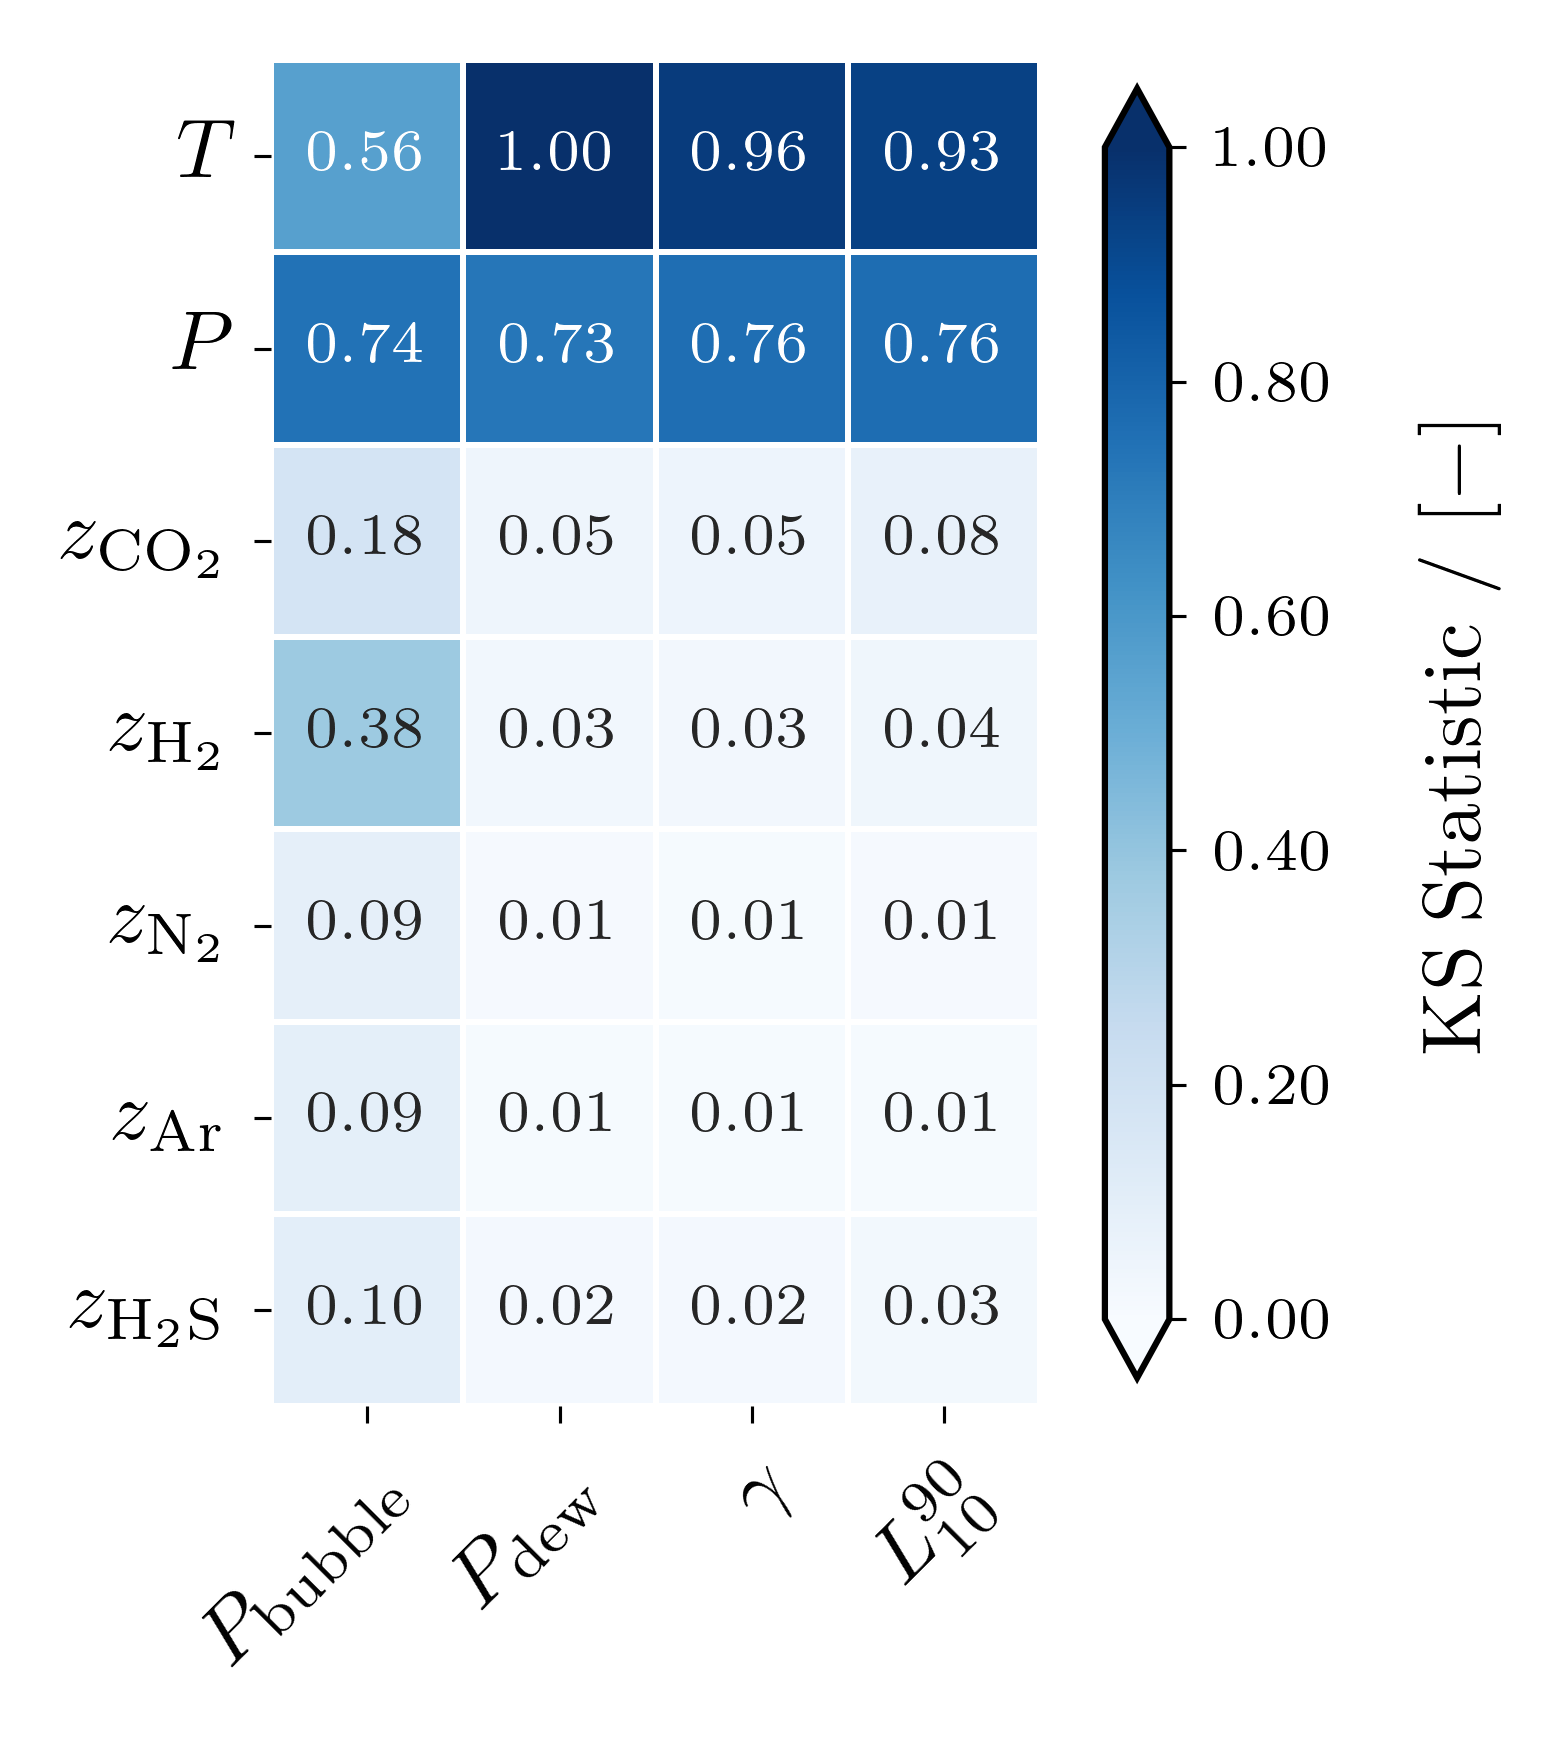

In [6]:
_math_fmt = FuncFormatter(lambda x, _: rf"${x:.2f}$")

# ── shared variables (inherited from cell 2) ────────────────────────────
# features = T, P + all z_i compositions
z_features    = ["temperature", "pressure"] + [
    c for c in combined_df.columns
    if c.startswith('z_') and combined_df[c].nunique() > 1
]
targets_ev    = ["P_bubble", "P_dew", "gamma", "interfacial_thickness"]
target_labels = [r"$P_{\mathrm{bubble}}$", r"$P_{\mathrm{dew}}$",
                  r"$\gamma$", r"$L^{90}_{10}$"]
feat_labels   = [label_map.get(f, f) for f in z_features]

# ── KS Statistic per impurity × target ───────────────────────────────────
# KS test compares the target distribution between low- and high-
# concentration groups (split at the median of each z_i).

ks_stat = np.zeros((len(z_features), len(targets_ev)))

for i, feat in enumerate(z_features):
    med  = combined_df[feat].median()
    low  = combined_df[combined_df[feat] <  med]
    high = combined_df[combined_df[feat] >= med]
    for j, tgt in enumerate(targets_ev):
        lo = low[tgt].dropna().values
        hi = high[tgt].dropna().values
        if len(lo) > 1 and len(hi) > 1:
            ks_stat[i, j], _ = ks_2samp(lo, hi)
        else:
            ks_stat[i, j] = np.nan

# Remove features with negligible influence (max KS < 0.02 across all targets)
keep         = np.nanmax(ks_stat, axis=1) >= 0.02
ks_stat_f    = ks_stat[keep]
feat_labels_f = [l for l, k in zip(feat_labels, keep) if k]

# ── plot ─────────────────────────────────────────────────────────────────
ks_df      = pd.DataFrame(ks_stat_f, index=feat_labels_f, columns=target_labels)
ks_annot   = ks_df.map(lambda v: rf"${v:.2f}$" if not np.isnan(v) else "")
cell_size  = 0.3
n_r, n_c   = len(feat_labels_f), len(targets_ev)
fig_h      = max(3.0, n_r * cell_size)
fig_w      = max(3.0, n_c * cell_size)
fig, ax    = ps.plot_init(w=fig_w, h=fig_h)

cm_ks = sns.heatmap(
    ks_df, ax=ax,
    annot=ks_annot, fmt='',
    cmap='Blues', vmin=0, vmax=1,
    square=True, linewidths=0.5,
    annot_kws={'size': annot_size*0.5},
    cbar_kws={'shrink': 1, 'fraction': 0.05, 'extend': 'both'},
)

cbar_ks = cm_ks.collections[0].colorbar
cbar_ks.ax.tick_params(width=ps.tick_width/2, length=ps.tick_length/2,
                        labelsize=ps.label_fontsize/2)
cbar_ks.set_label(r"$\mathrm{KS \; Statistic}$ / $[-]$", fontsize=10, labelpad=10)
cbar_ks.outline.set_linewidth(0.75)

ps.apply_axis_style(ax)
ax.tick_params(axis='x', which='both', direction='out',
               length=ps.tick_length/2, width=ps.tick_width/2,
               labelsize=ps.label_fontsize/2,
               bottom=True, top=False, labelbottom=True, labeltop=False)
ax.tick_params(axis='y', which='both', direction='out',
               length=ps.tick_length/2, width=ps.tick_width/2,
               labelsize=ps.label_fontsize/2,
               left=True, right=False, labelleft=True, labelright=False)

ax.set_xticks(np.arange(len(target_labels)) + 0.5)
ax.set_yticks(np.arange(len(feat_labels_f)) + 0.5)

ax.set_xticklabels(target_labels, rotation=45, ha='right', fontsize=10, rotation_mode='anchor')
ax.set_yticklabels(feat_labels_f, fontsize=10, rotation=0)

cbar_ks.ax.yaxis.set_major_formatter(_math_fmt)
plt.tight_layout()
ps.save_plot(fig, "ks_statistic")
plt.show()

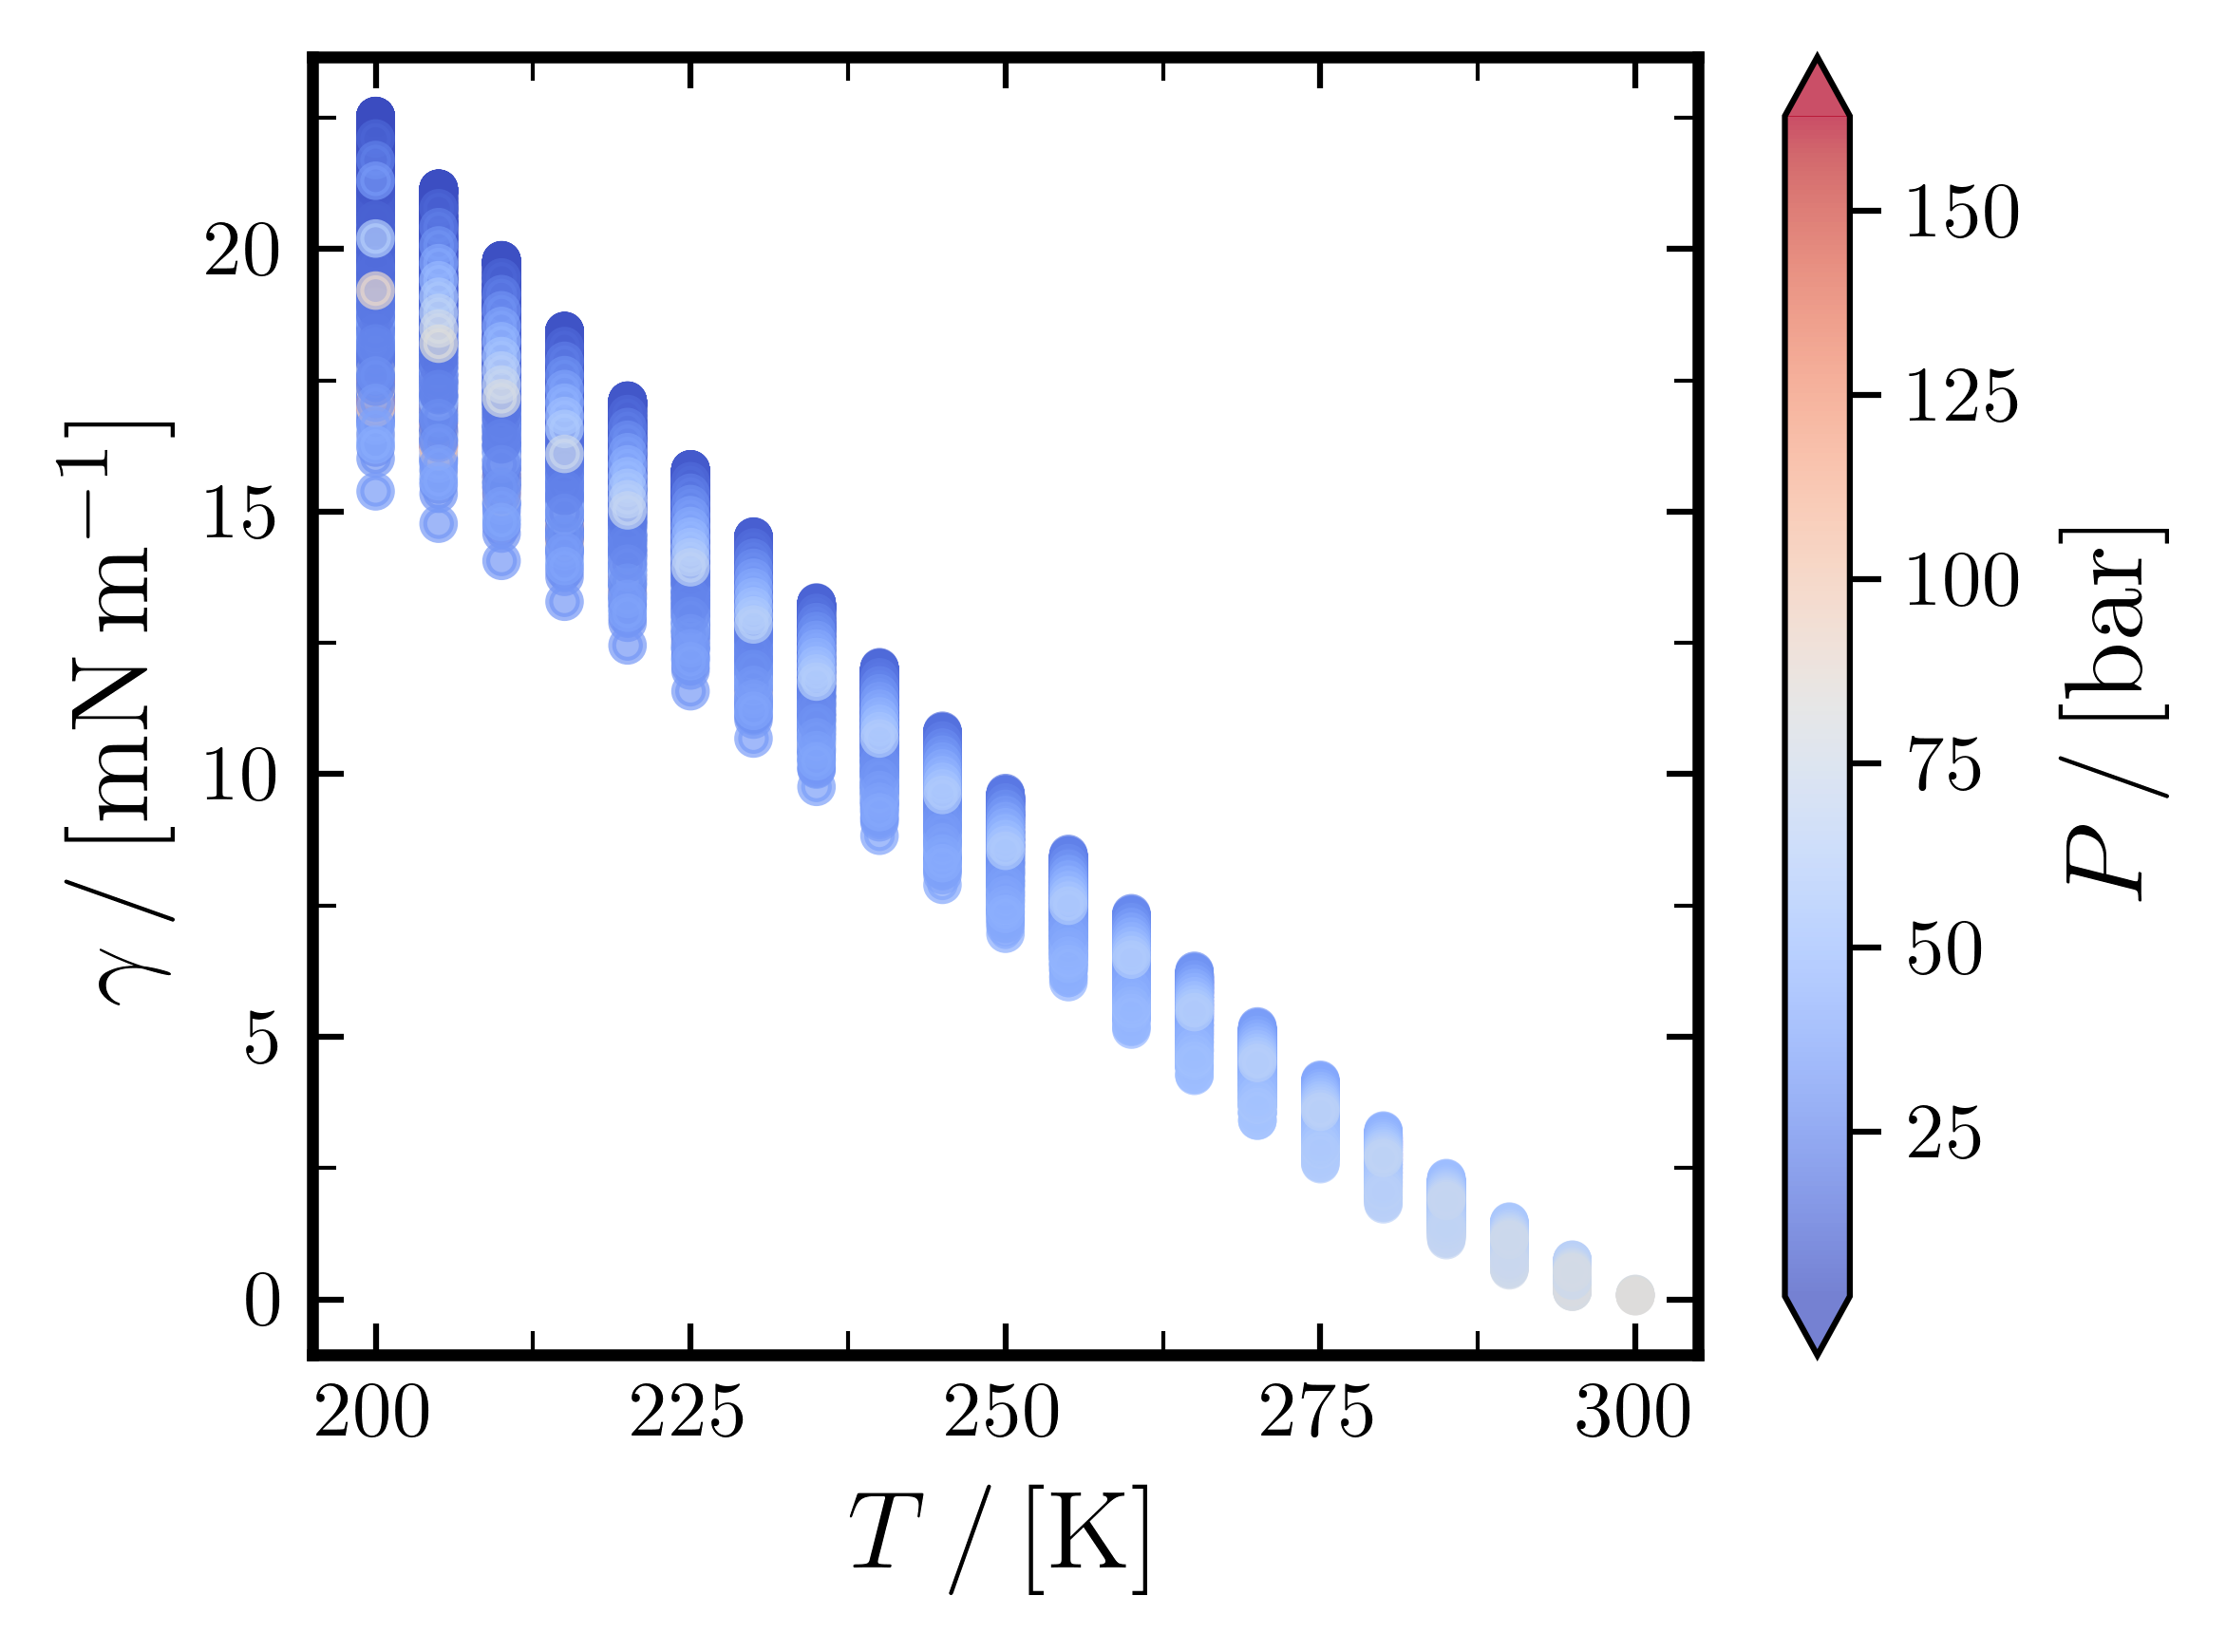

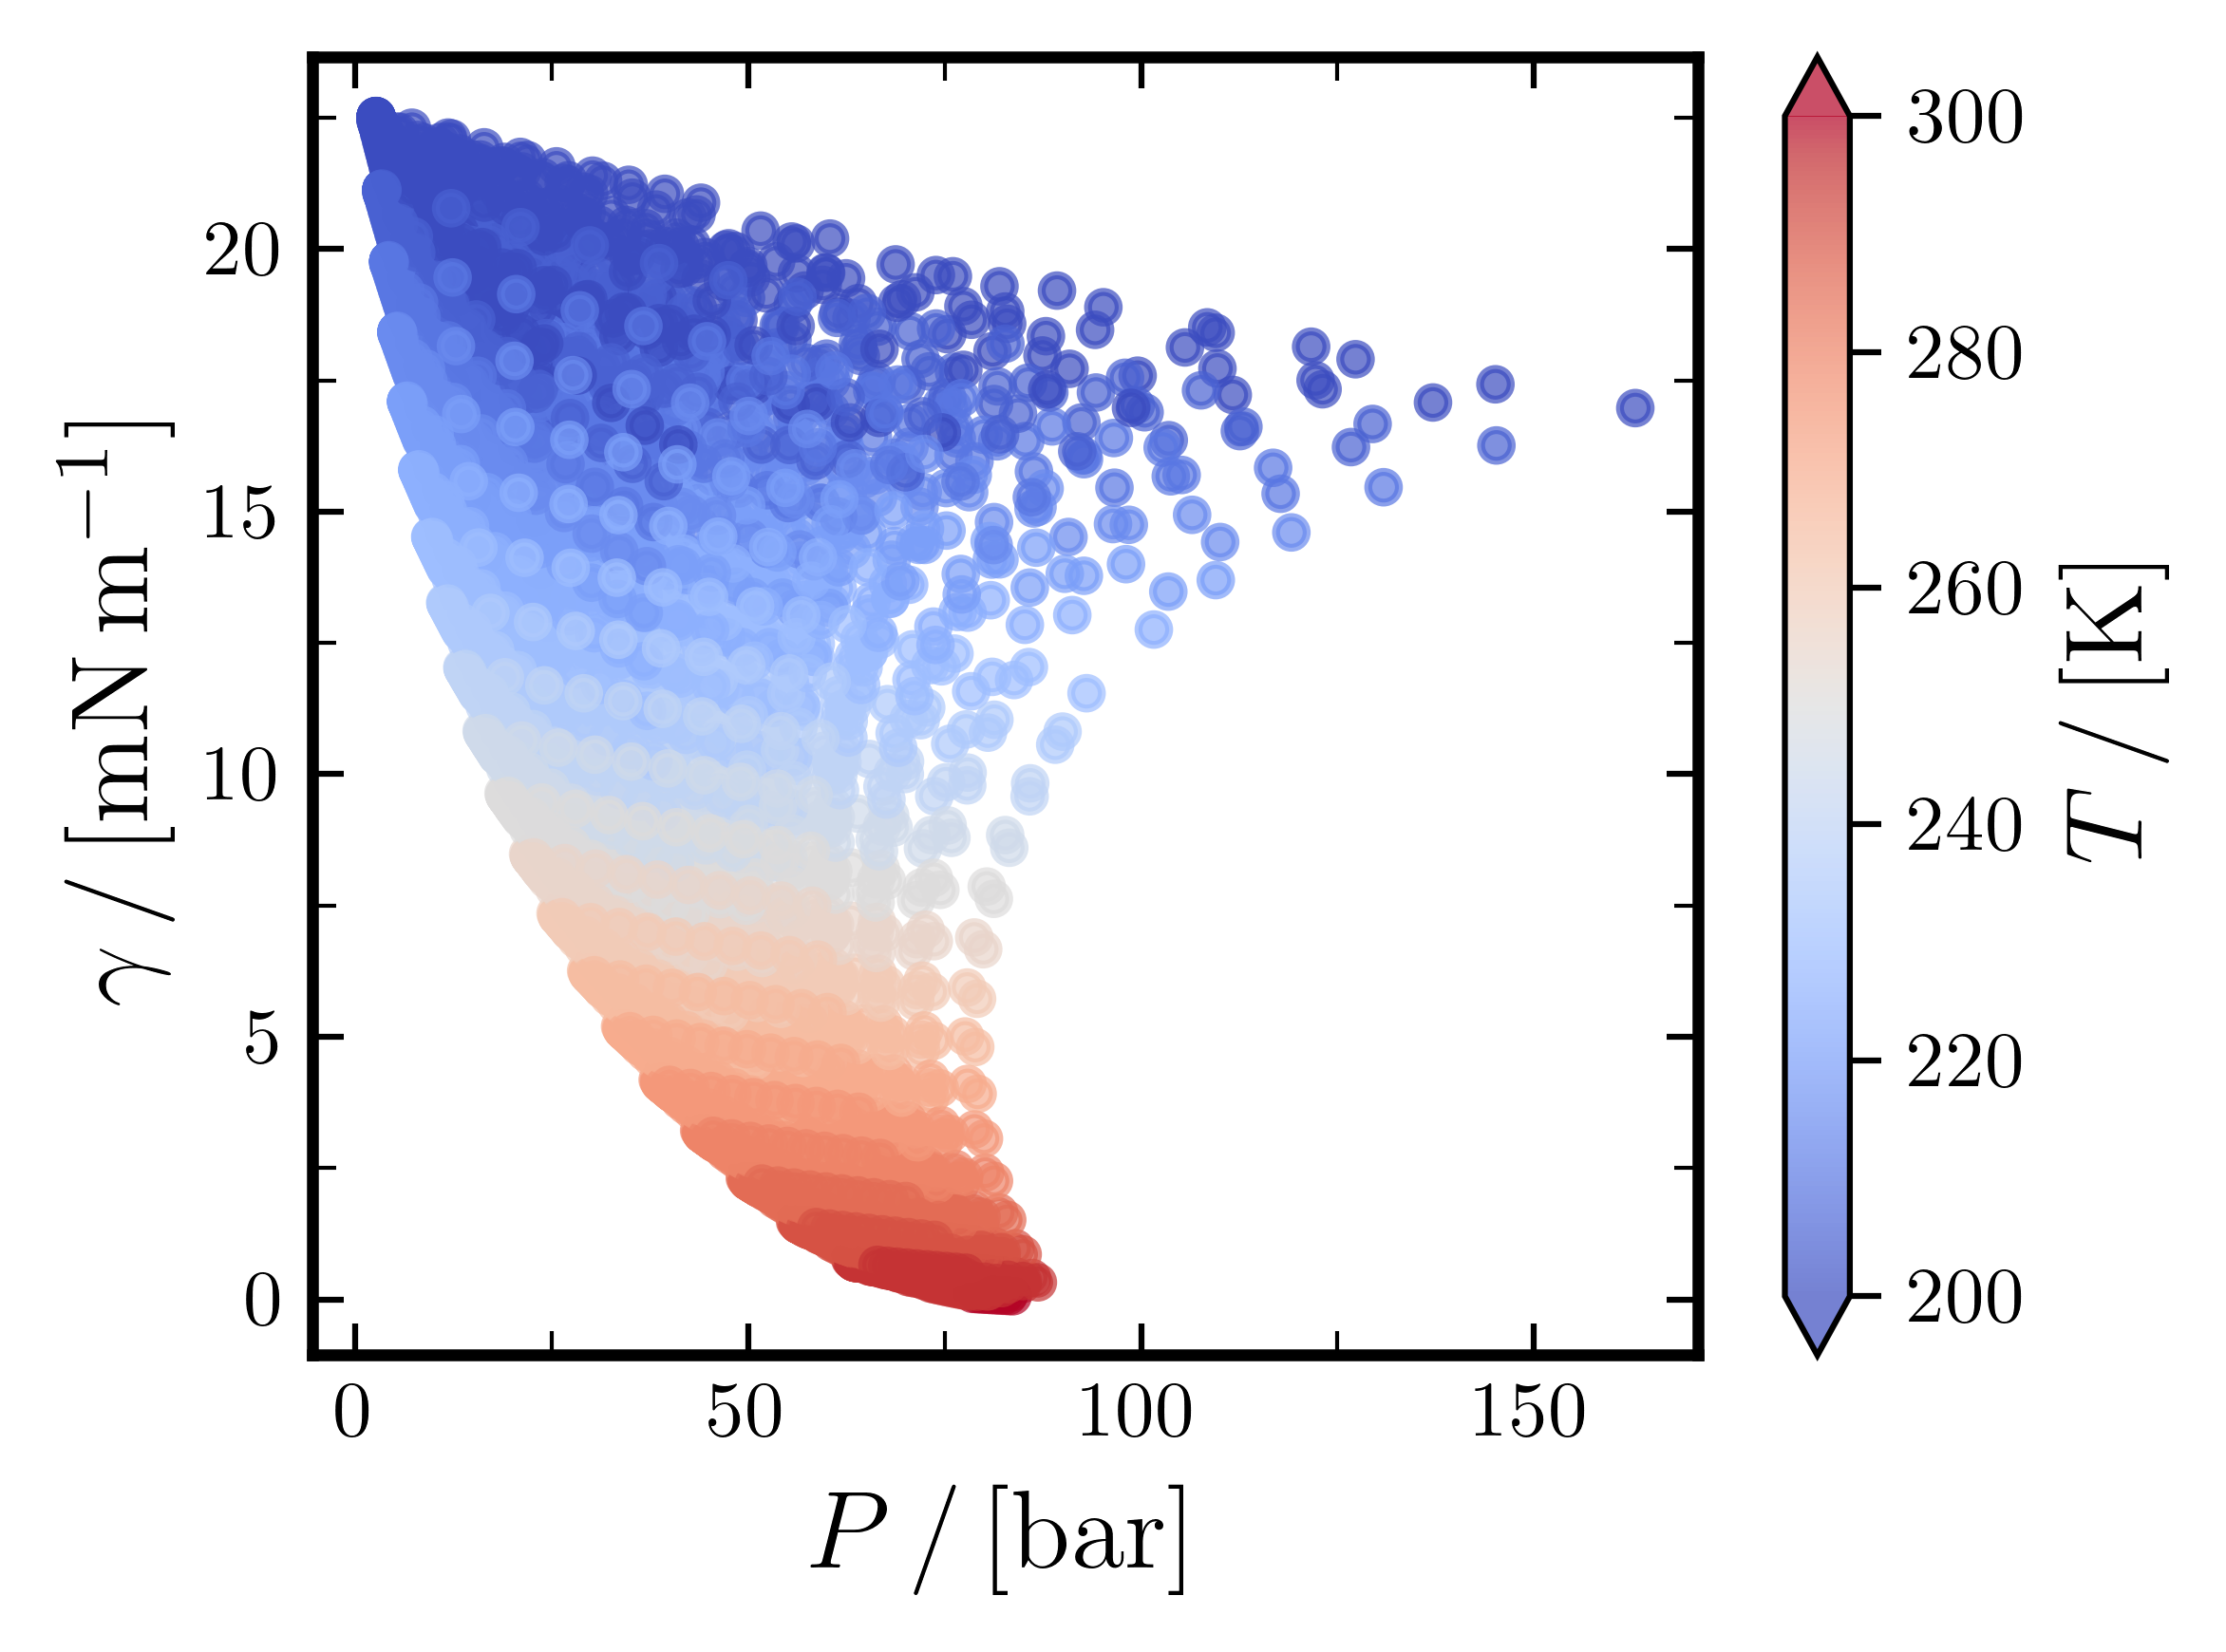

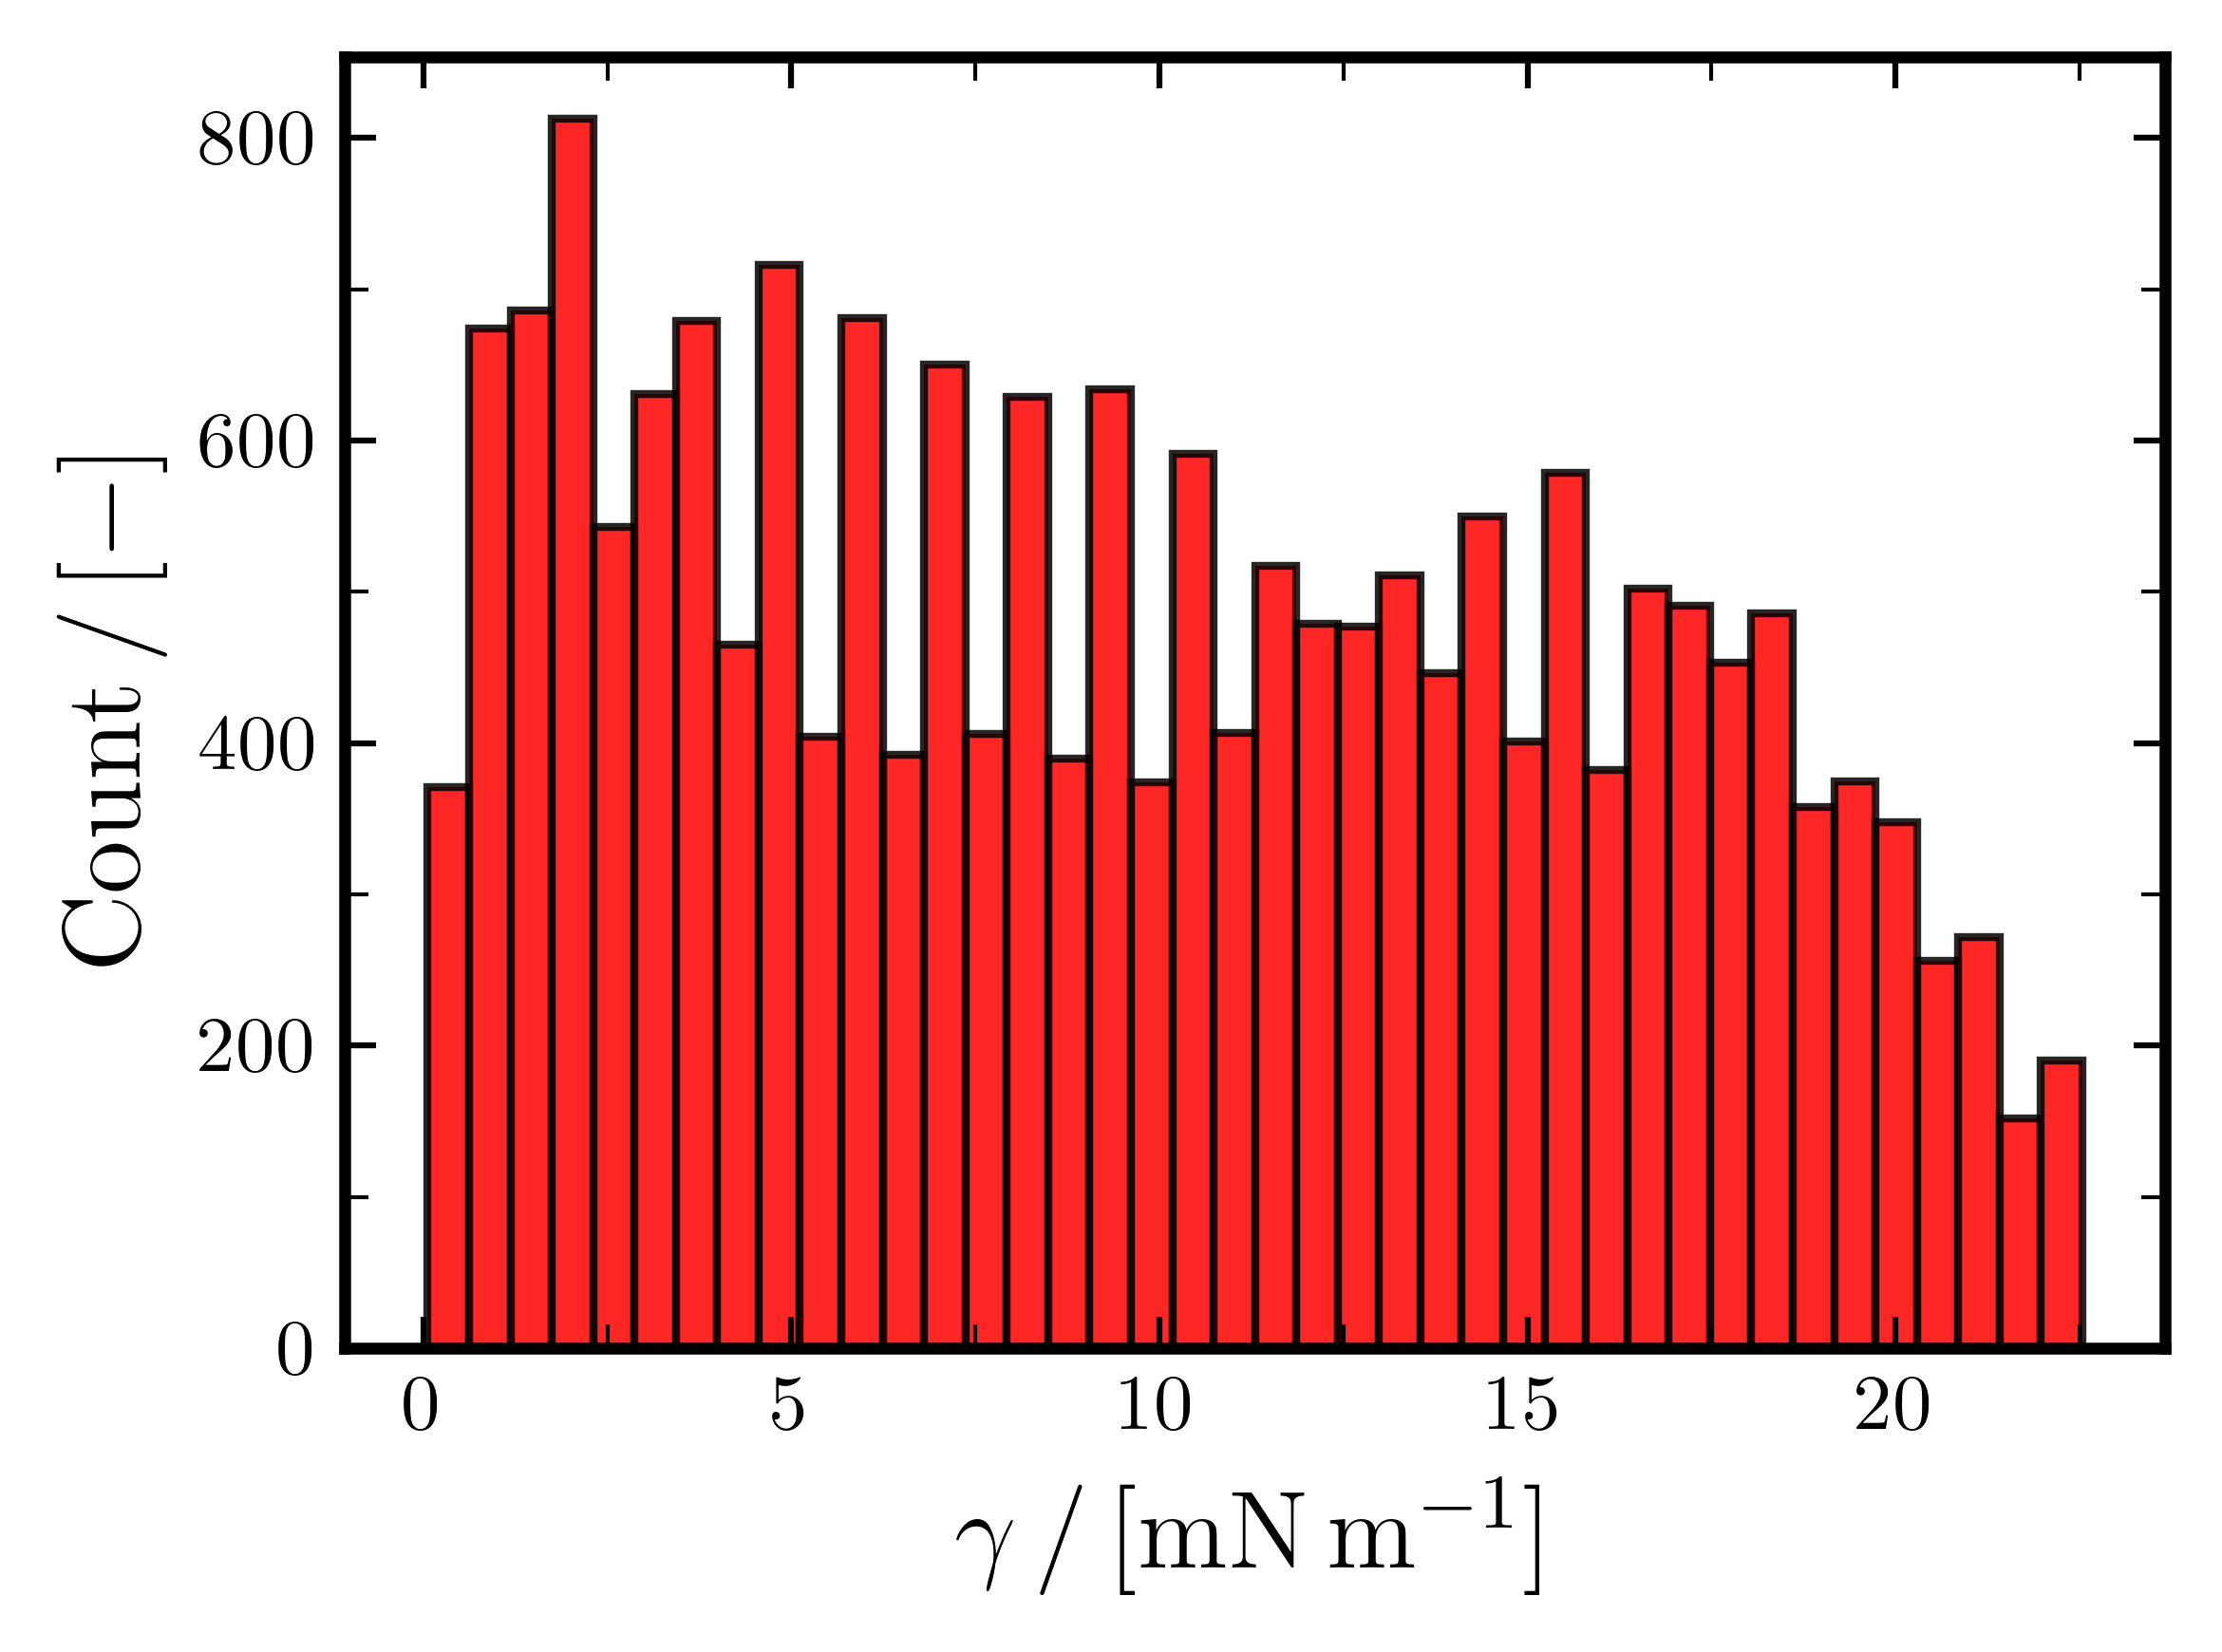

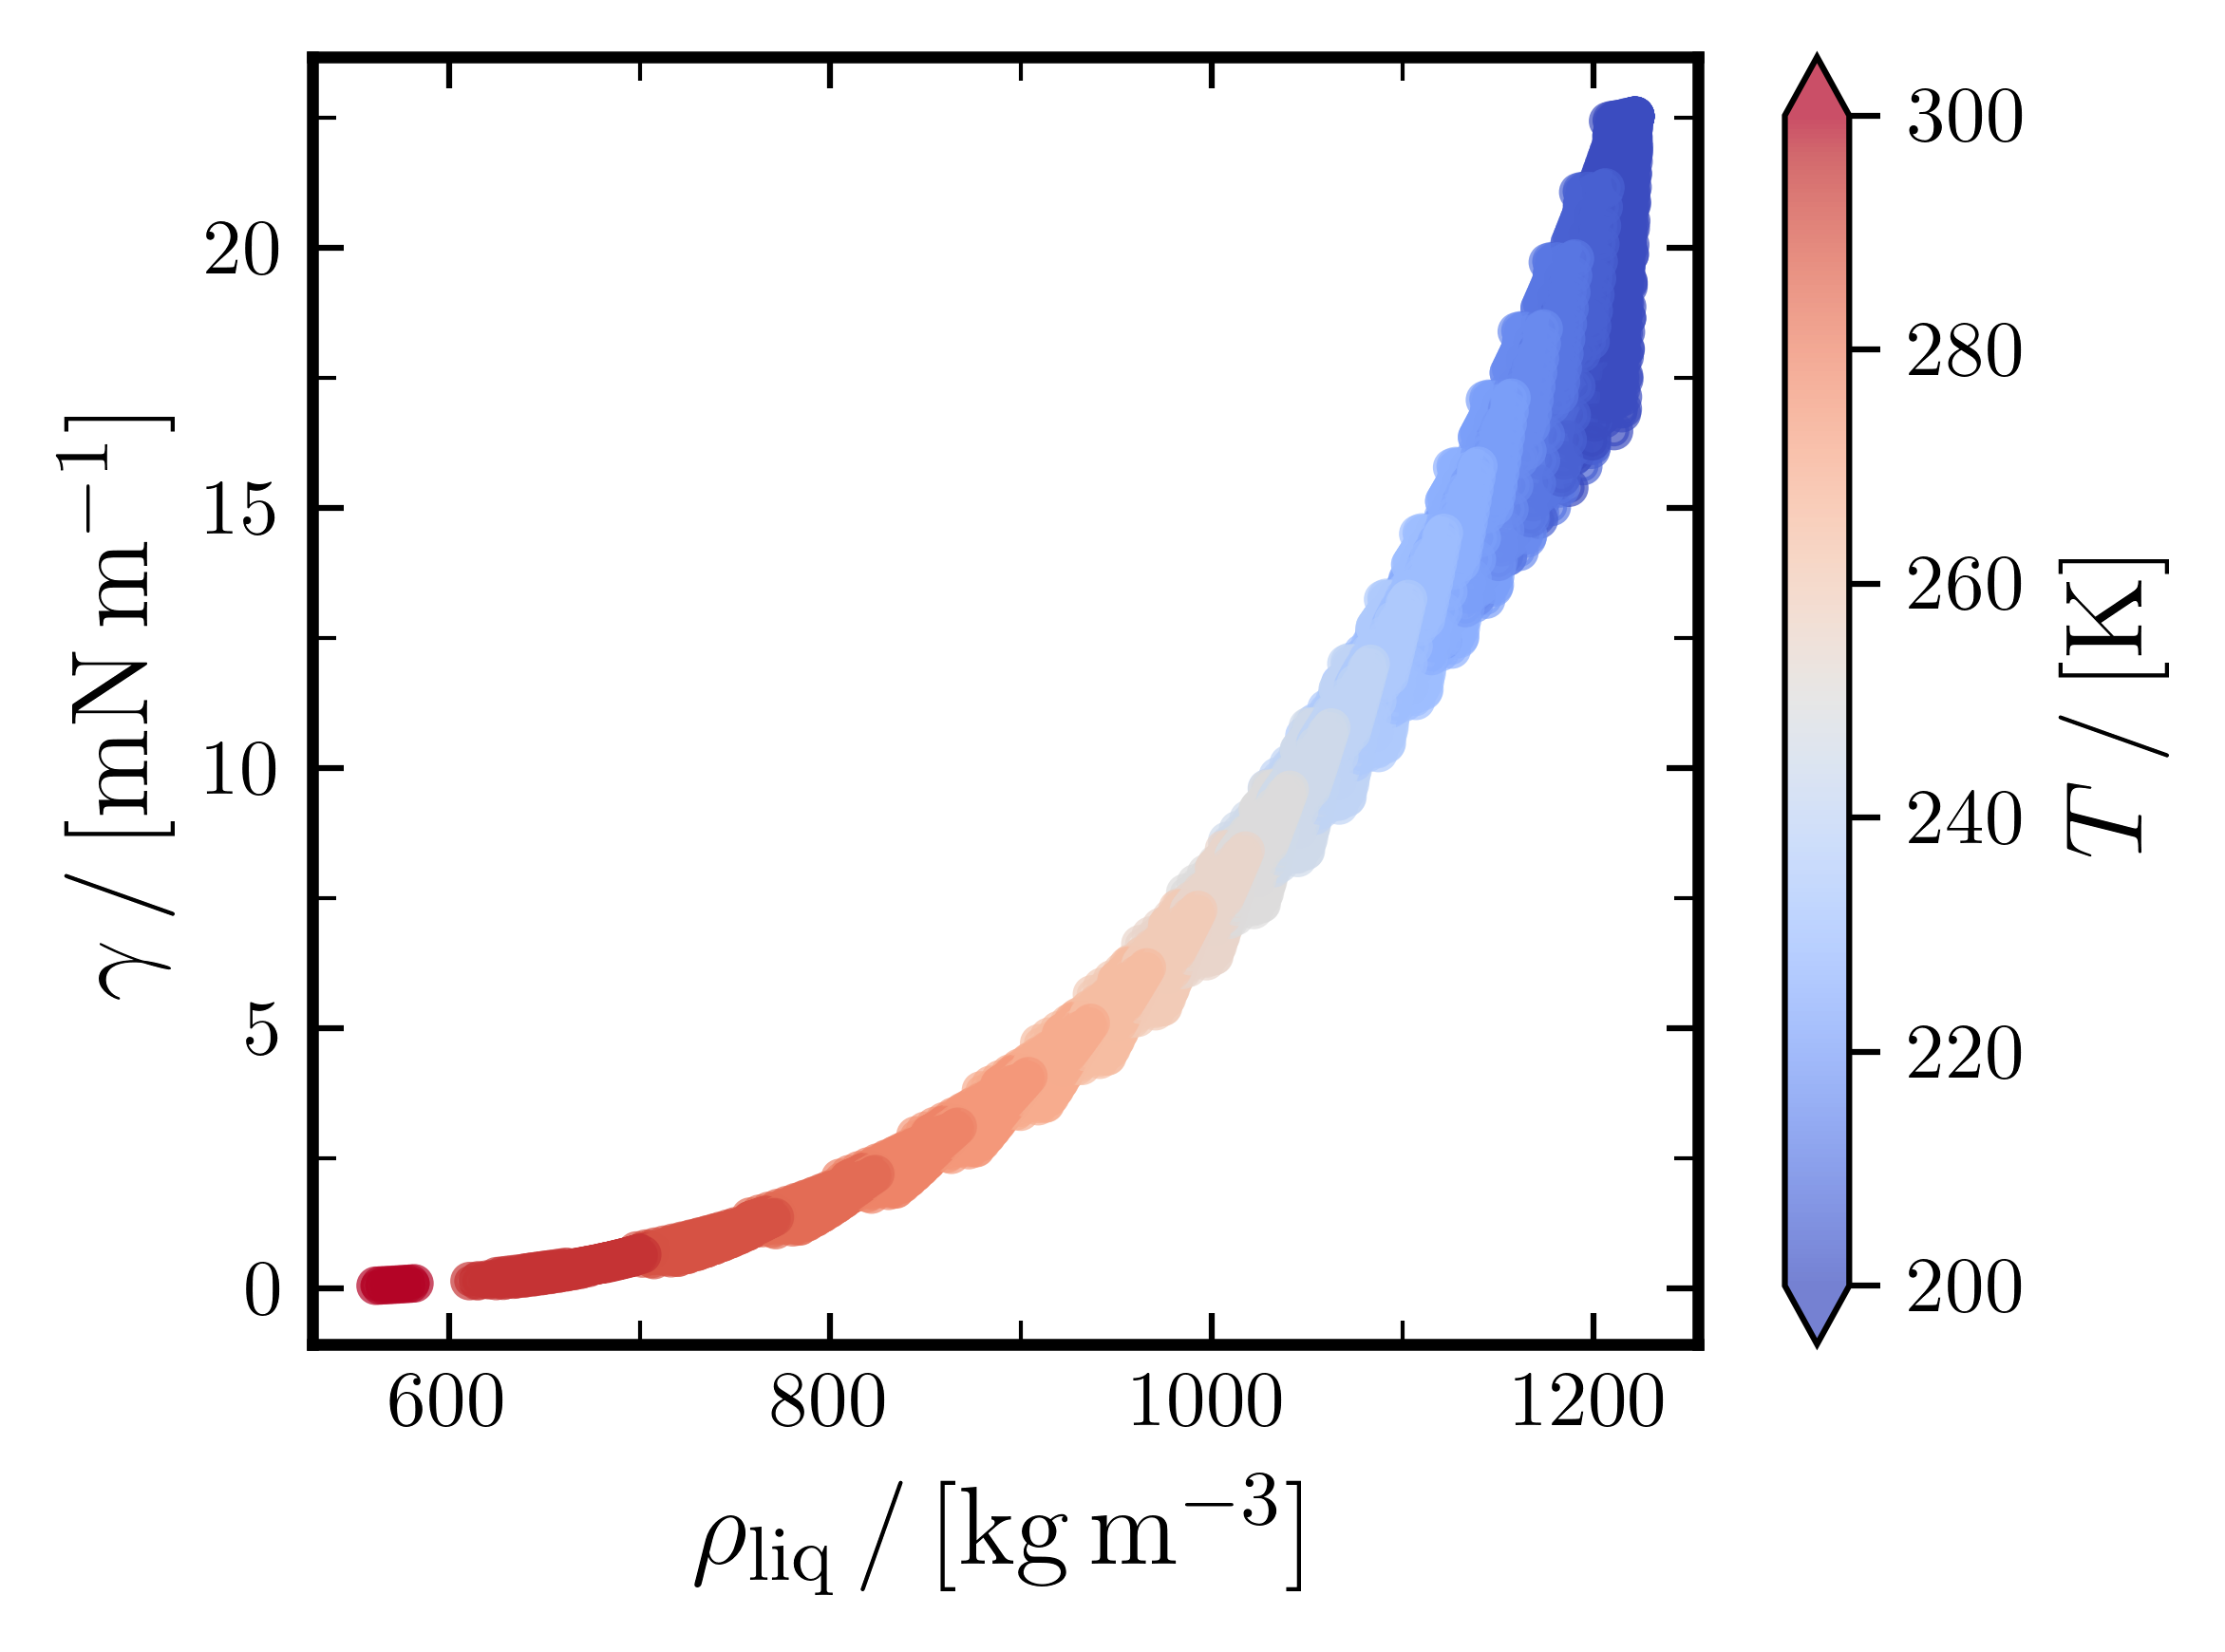

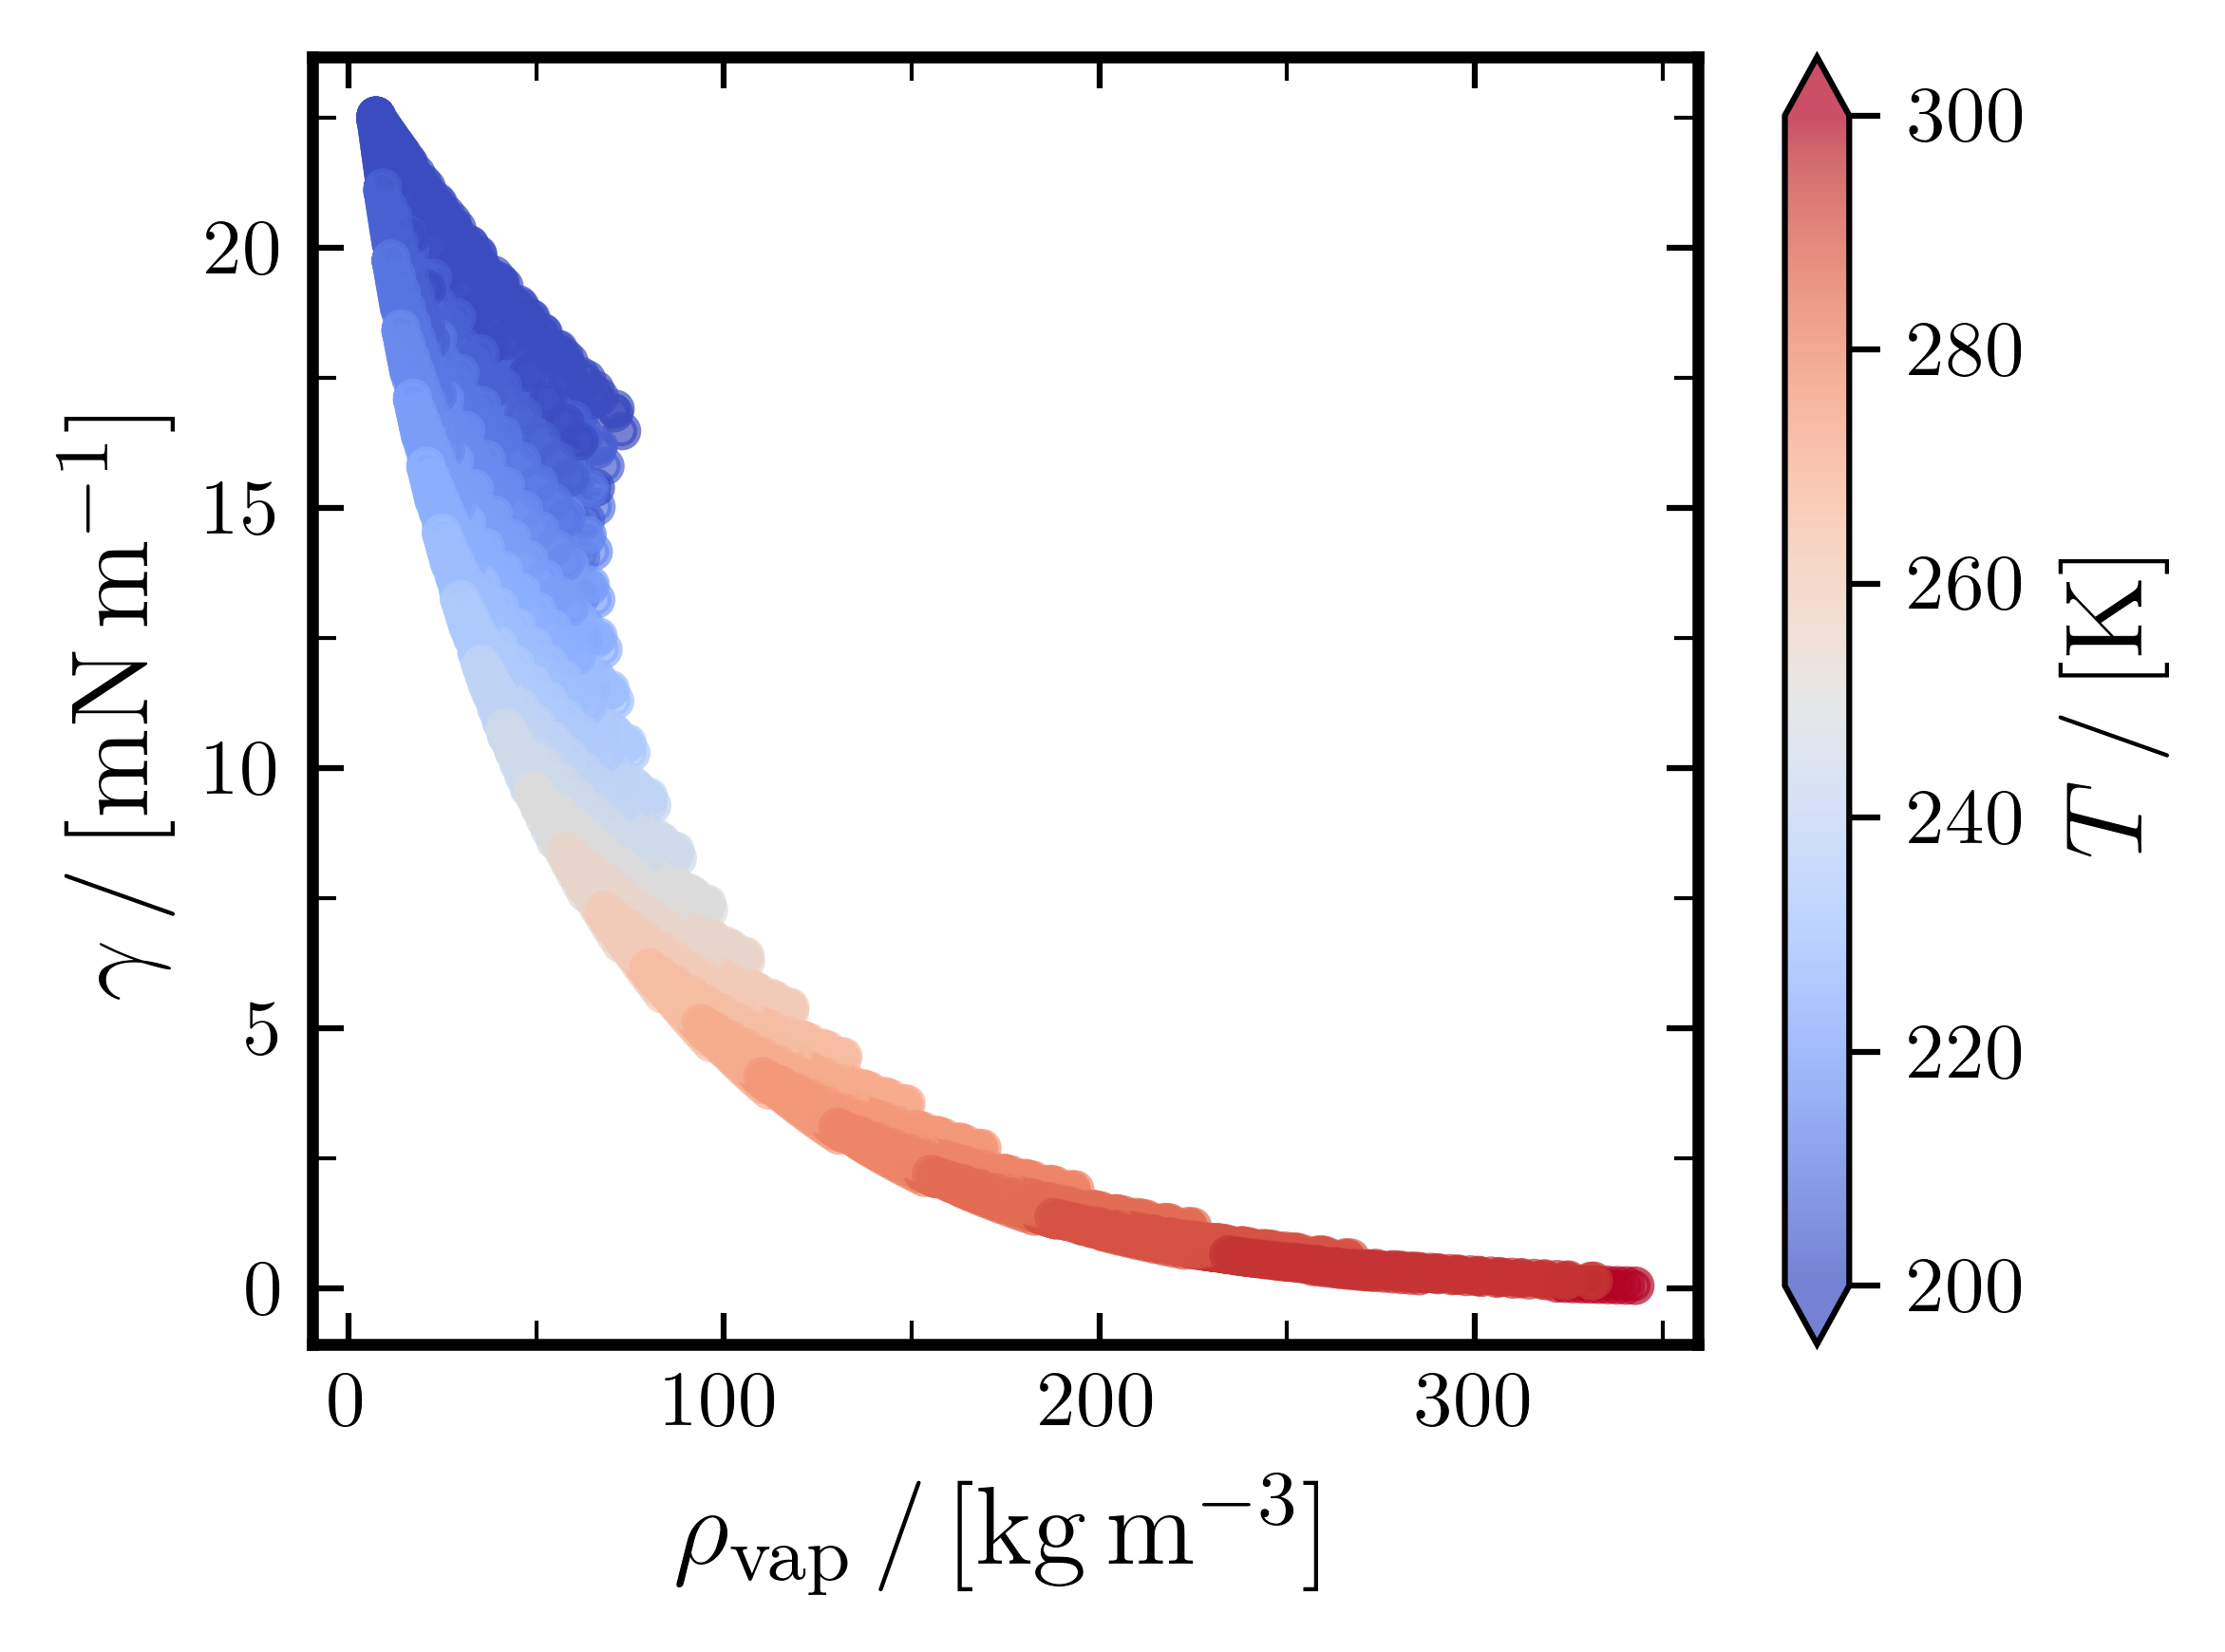

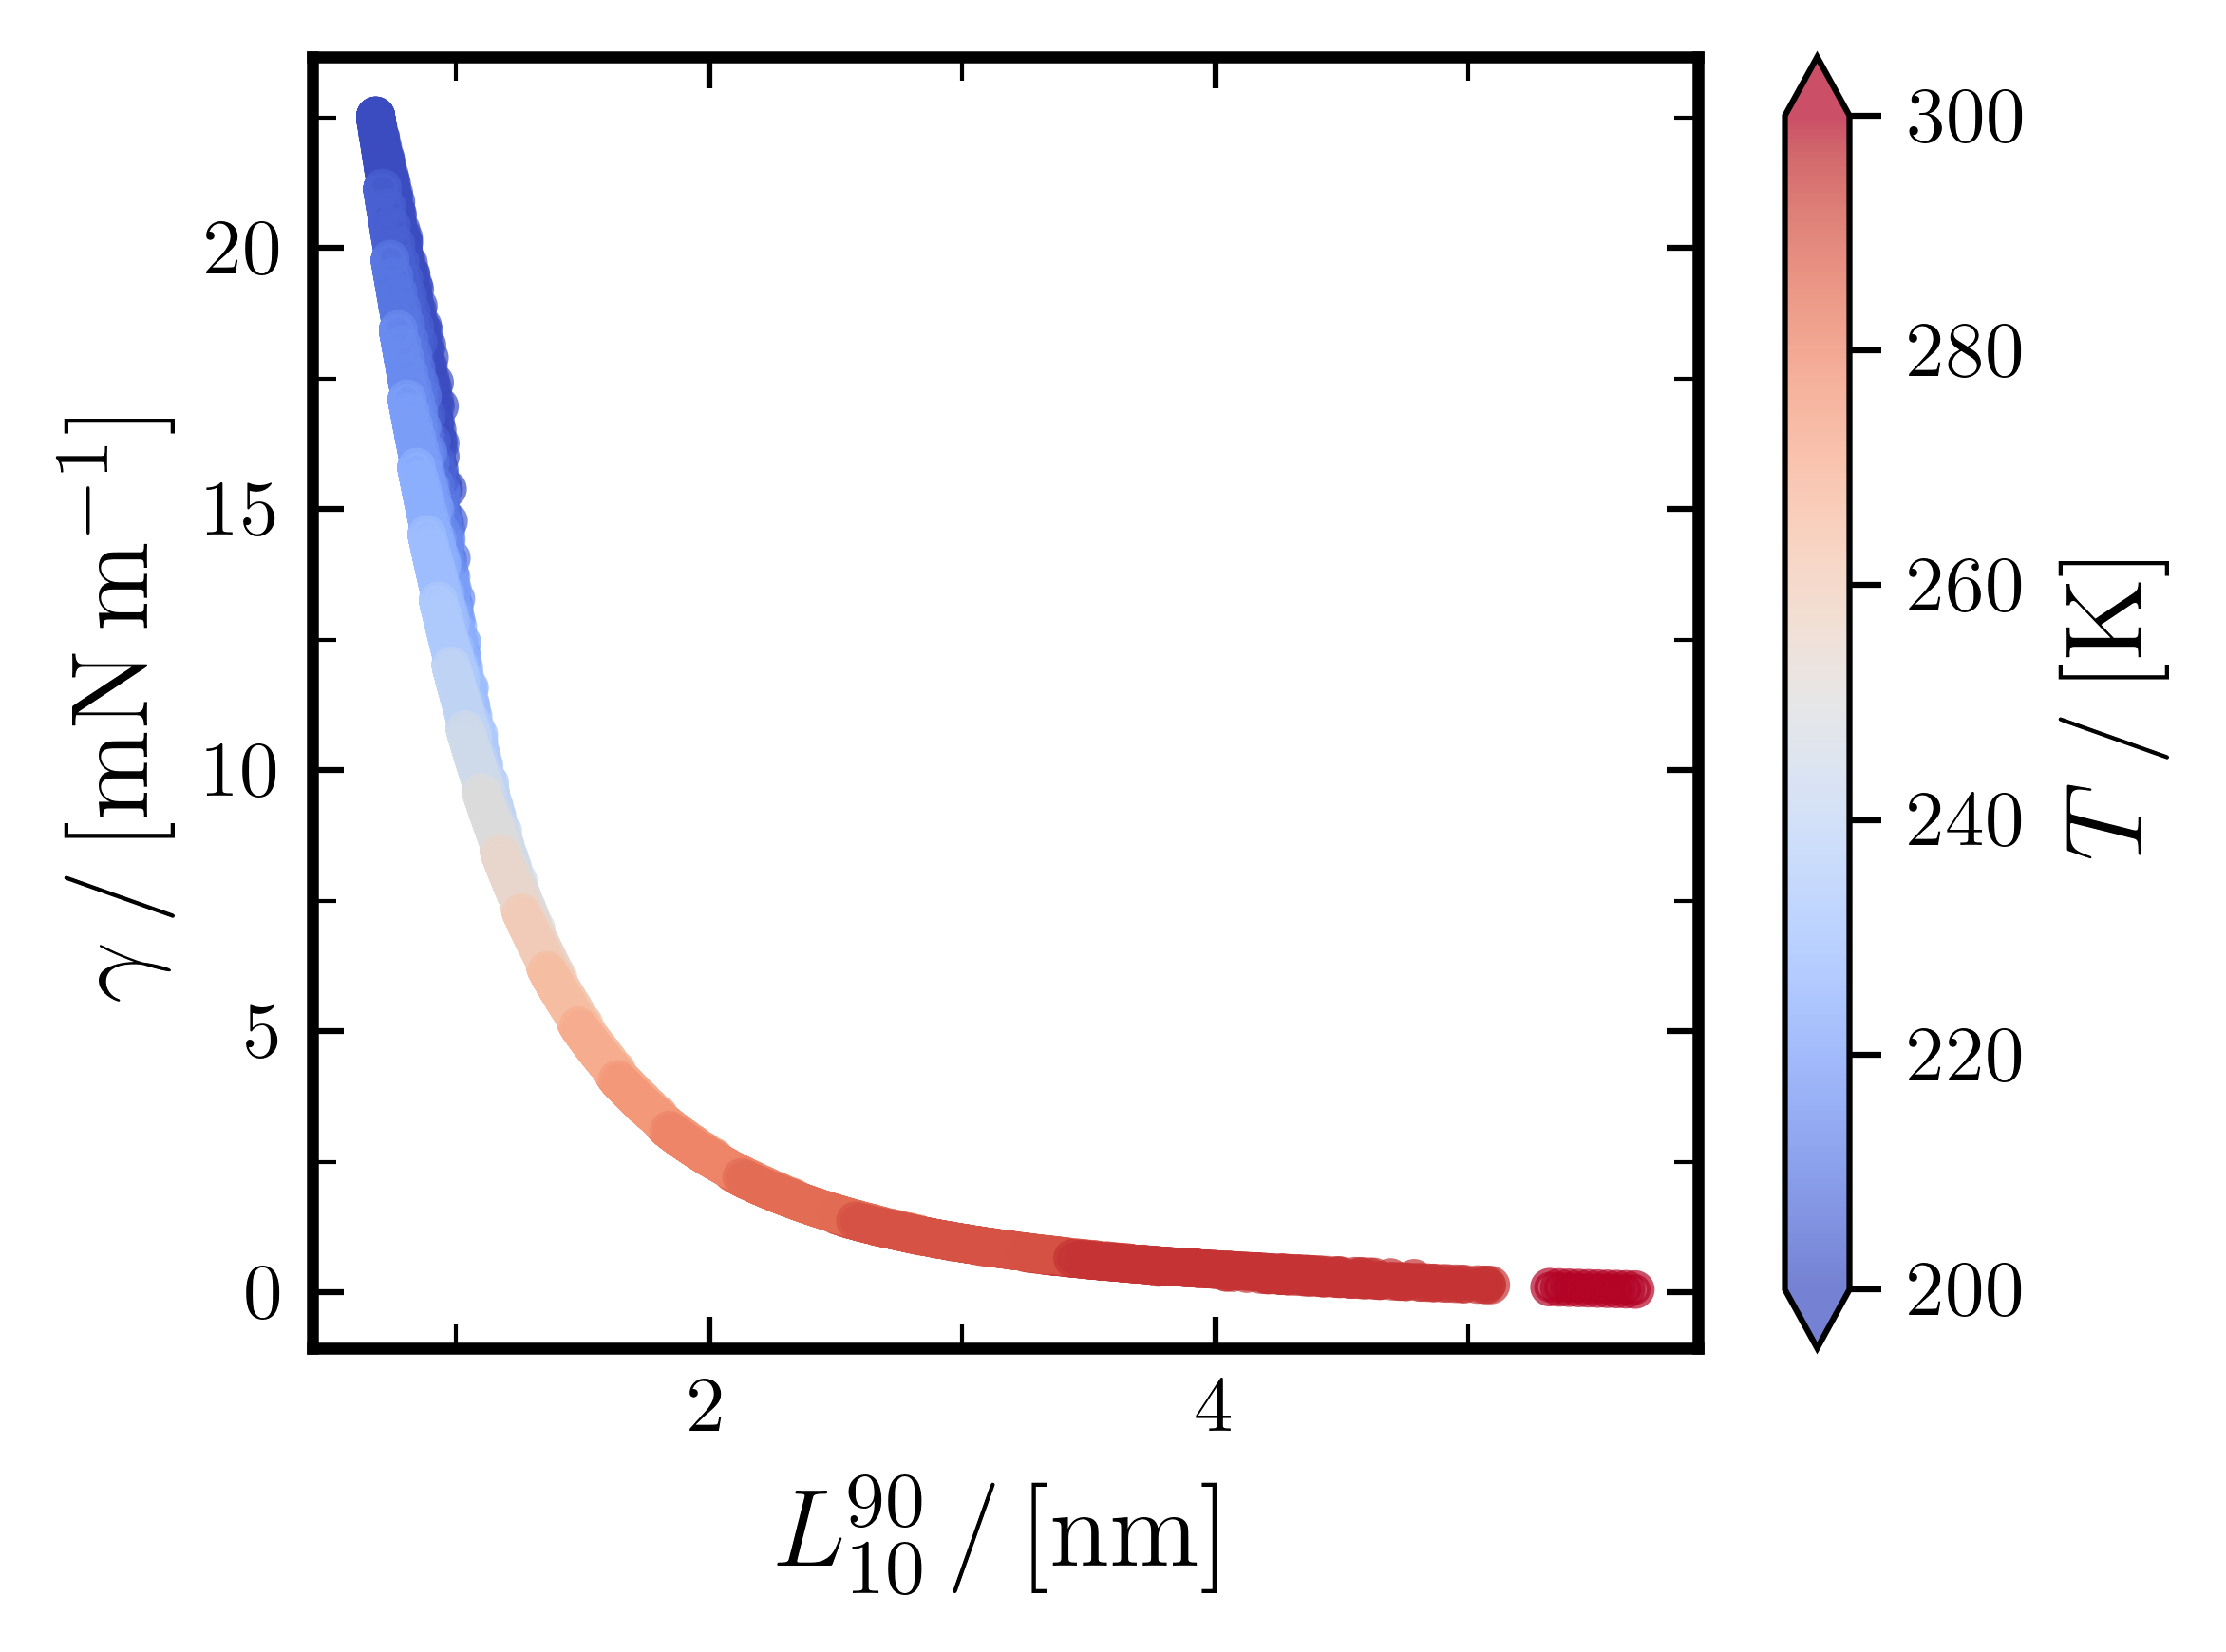

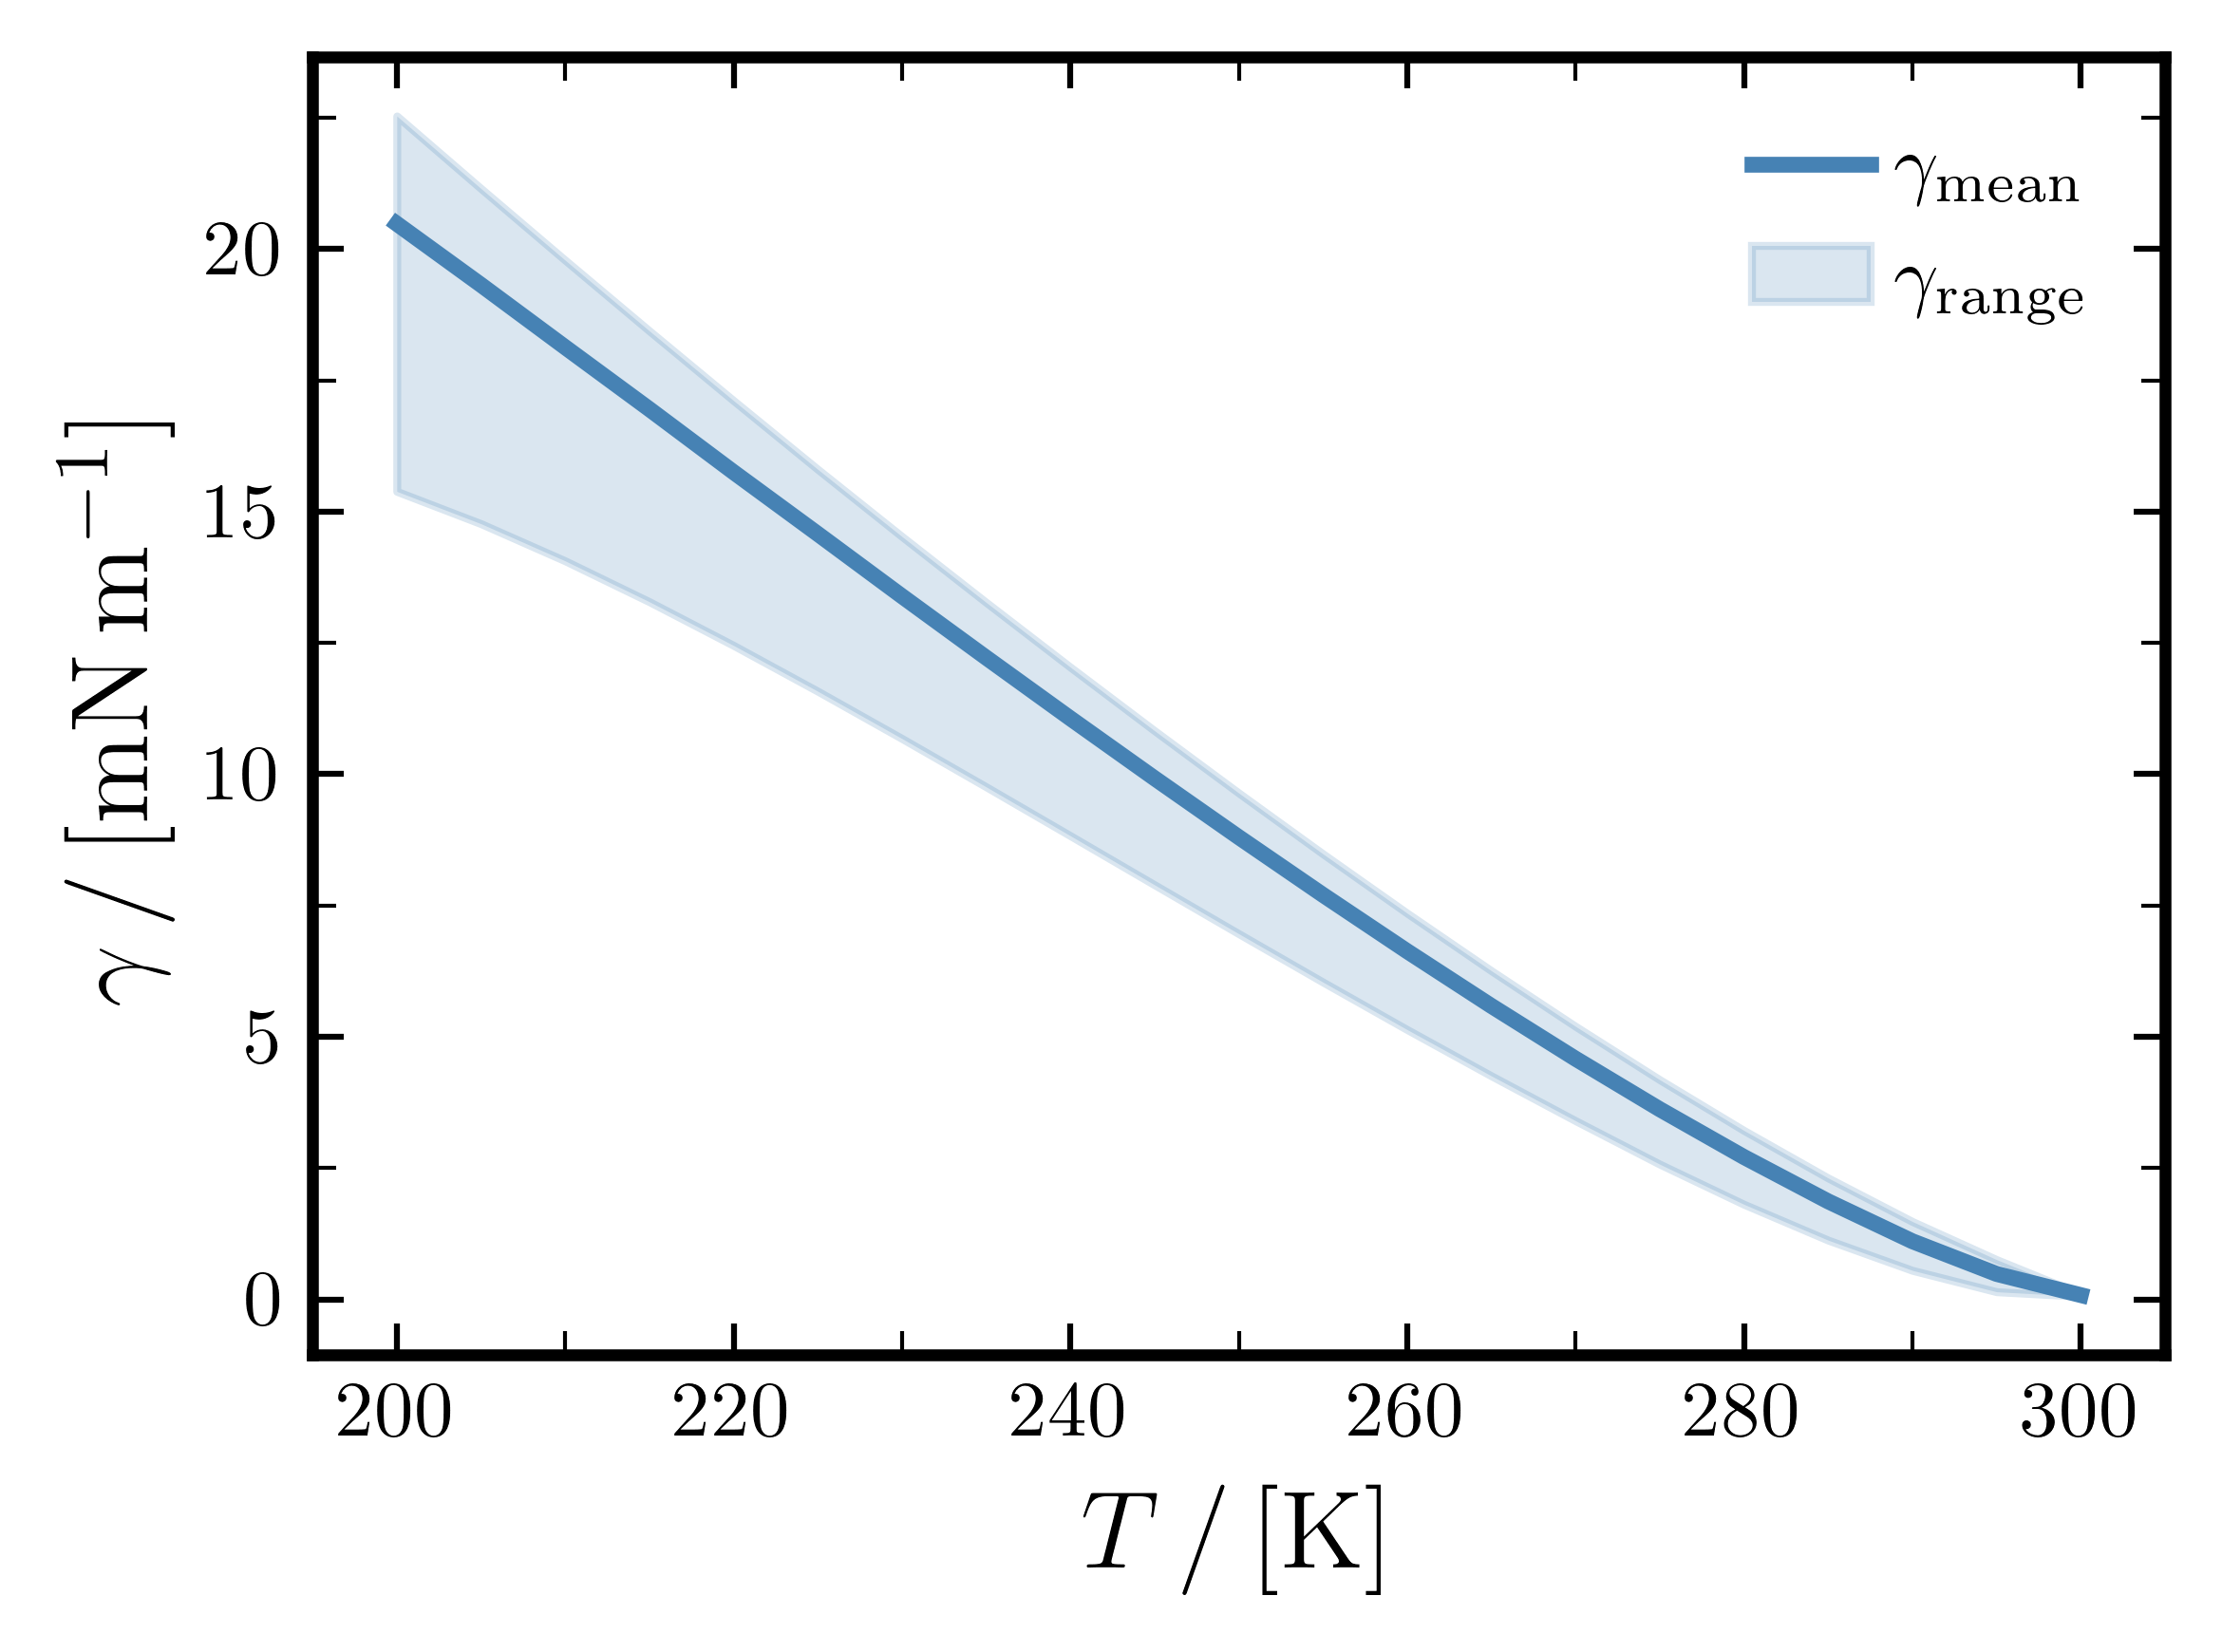

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$T \\, / \\, [\\mathrm{K}]$', ylabel='$\\gamma \\, / \\, [\\mathrm{mN} \\, \\mathrm{m}^{-1}]$'>)

In [5]:
target      = "gamma"
prep        = MLPreprocessing(df=combined_df, features=features, target=target)

prep.plot_target_vs_temperature(save_path="gamma_vs_T")
prep.plot_target_vs_pressure(save_path="gamma_vs_P")
prep.plot_target_distribution(save_path="gamma_distribution")
prep.plot_target_vs_liquid_density(save_path="gamma_vs_rhoL")
prep.plot_target_vs_vapor_density(save_path="gamma_vs_rhoV")
prep.plot_target_vs_interfacial_thickness(save_path="gamma_vs_thickness")
prep.plot_target_phase_envelope(save_path="gamma_phase_envelope")